In [5]:
import pandas as pd
import os
import json
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

RESULTS_DIR = "results/results_wikidyk_full_20_jsonl/"

In [6]:
def load_all_jsonls(results_dir):
    dfs = []
    for fname in glob(os.path.join(results_dir, "*.jsonl")):
        with open(fname, "r", encoding="utf-8") as fin:
            rows = [json.loads(line) for line in fin]
        dfs.append(pd.DataFrame(rows))
    return pd.concat(dfs, ignore_index=True)

df = load_all_jsonls(RESULTS_DIR)
print(f"Loaded {len(df)} rows from {RESULTS_DIR}")
display(df.head())

Loaded 124 rows from results/results_wikidyk_full_20_jsonl/


,identifier,fact_id,eval_type,run_id,question,correct_answer,fact,prediction,verdict,explanation
0,wikidyk_20__17__paraphrase,17,paraphrase,wikidyk_20,Which journalist was taken aback by a radio ad...,Bill Fleischman,when journalist Bill Fleischman was surprised ...,**Summary:** Retrieved information about journ...,CORRECT,
1,wikidyk_20__6__paraphrase,6,paraphrase,wikidyk_20,Who is the Zimbabwean colonel that was involve...,Flint Magama,"Zimbabwean colonel Flint Magama, who was respo...",**Summary:** Retrieved information from memory...,CORRECT,
2,wikidyk_20__6__counterfactual,6,counterfactual,wikidyk_20,"that Zimbabwean colonel Flint Magama, who was ...",false,"Zimbabwean colonel Flint Magama, who was respo...",**Summary:** Retrieved information about Flint...,CORRECT,
3,wikidyk_20__3__reliability,3,reliability,wikidyk_20,What is the name of the video game developed i...,Pyongyang Racer,the video game Pyongyang Racer was developed i...,**Summary:** Retrieved information about the N...,CORRECT,
4,wikidyk_20__16__reliability,16,reliability,wikidyk_20,Which British coin was criticized for being to...,Double florin,"the double florin (example pictured), a Britis...",**Summary:** Retrieved information about the c...,CORRECT,


In [3]:
def compute_overall_metrics(df):
    total = len(df)
    correct = (df['verdict'] == 'CORRECT').sum()
    incorrect = (df['verdict'] == 'INCORRECT').sum()
    accuracy = correct / total if total else float("nan")
    print(f"Total: {total}")
    print(f"Correct: {correct} ({accuracy:.2%})")
    print(f"Incorrect: {incorrect} ({incorrect/total:.2%})")
    return {"total": total, "correct": correct, "incorrect": incorrect, "accuracy": accuracy}

metrics = compute_overall_metrics(df)

Total: 124
Correct: 116 (93.55%)
Incorrect: 8 (6.45%)


In [4]:
def group_accuracy(df, by='eval_type'):
    stats = df.groupby(by)['verdict'].apply(lambda x: (x == "CORRECT").mean())
    return stats.reset_index(name='accuracy').sort_values('accuracy', ascending=False)

df_style_acc = group_accuracy(df, by="eval_type")
print("Per-style accuracy:")
display(df_style_acc)

df_event_acc = group_accuracy(df, by="fact")
print("Per-event accuracy:")
display(df_event_acc)

Per-style accuracy:


,eval_type,accuracy
2,generality,1.000000
0,counterfactual,0.950000
1,factual,0.950000
6,reliability,0.950000
3,locality,0.916667
4,paraphrase,0.900000
5,portability,0.833333


Per-event accuracy:


,fact,accuracy
0,AI expert Tess Posner resigned her role as a C...,1.000000
9,after going off the air due to financial issue...,1.000000
18,the video game Pyongyang Racer was developed i...,1.000000
17,the vegan-food brand Squeaky Bean produces foo...,1.000000
15,"the double florin (example pictured), a Britis...",1.000000
13,the Port of Shahid Rajaee is responsible for 8...,1.000000
12,the BP Building features Europe's first exampl...,1.000000
11,"in 2019, Paul Cosford and his colleagues found...",1.000000
1,"Da'ud, the heir apparent of the last Fatimid c...",1.000000
10,"at various secondary schools and universities,...",1.000000


In [8]:
from statistics import median

accuracies = list(df_event_acc.to_dict()["accuracy"].values())

ac_mean = sum(accuracies) / len(accuracies)
ac_std = (sum((x - ac_mean) ** 2 for x in accuracies) / len(accuracies)) ** 0.5
ac_median = median(accuracies)
print(f"Mean accuracy on possible cases: {ac_mean:.2%} (std: {ac_std:.2%})")
print(f"Median accuracy on possible cases: {ac_median:.2%}")

Mean accuracy on possible cases: 94.29% (std: 13.09%)
Median accuracy on possible cases: 100.00%


In [8]:
def show_sample_errors(df, group_by=None, n=5):
    errors = df[df['verdict'] != 'CORRECT']
    if group_by:
        errors = errors[errors[group_by] == group_by]
    if len(errors) > 0:
        display(errors.sample(min(n, len(errors))))
    else:
        print("No errors found.")

print("Sample errors:")
show_sample_errors(df, n=1)

Sample errors:


,identifier,fact_id,eval_type,run_id,question,correct_answer,fact,prediction,verdict,explanation
6,test1_wikidyk/0/counterfactual,0,counterfactual,test1_wikidyk,Umar Zahir built neither an island of trash no...,false,Umar Zahir built both an island of trash and a...,**Summary:** Evaluated statement against known...,INCORRECT,INCORRECT\n\nThe test answer reaches the corre...


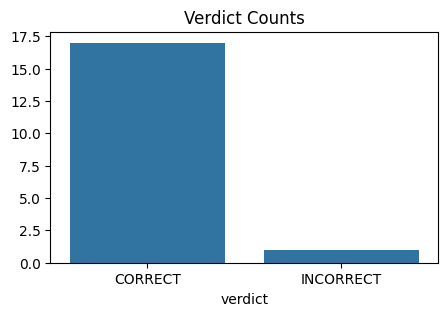

In [9]:
if "verdict" in df.columns:
    verdict_counts = df['verdict'].value_counts()
    plt.figure(figsize=(5,3))
    sns.barplot(x=verdict_counts.index, y=verdict_counts.values)
    plt.title("Verdict Counts")
    plt.show()

if "possible" in df.columns:
    possible_acc = df[df['possible'] == True]['verdict'].eq('CORRECT').mean()
    print(f"Accuracy when answer is possible: {possible_acc:.2%}")
    impossible_acc = df[df['possible'] == False]['verdict'].eq('CORRECT').mean()
    print(f"Accuracy when answer is NOT possible: {impossible_acc:.2%}")
